In [6]:
import cv2
import numpy as np

def sobel(image):
    # Define Sobel kernels
    sobel_x = np.array([[ -1, 0, 1],
                         [ -2, 0, 2],
                         [ -1, 0, 1]])
    
    sobel_y = np.array([[ 1, 2, 1],
                         [ 0, 0, 0],
                         [-1,-2,-1]])
    
    # Convolve image with Sobel kernels
    grad_x = cv2.filter2D(image, cv2.CV_64F, sobel_x)
    grad_y = cv2.filter2D(image, cv2.CV_64F, sobel_y)
    
    # Compute gradient magnitude
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    # Normalize to range [0, 255]
    gradient_magnitude = (gradient_magnitude / np.max(gradient_magnitude)) * 255
    return gradient_magnitude.astype(np.uint8)

def prewitt(image):
    # Define Prewitt kernels
    prewitt_x = np.array([[ -1, 0, 1],
                          [ -1, 0, 1],
                          [ -1, 0, 1]])
    
    prewitt_y = np.array([[ 1, 1, 1],
                          [ 0, 0, 0],
                          [-1,-1,-1]])
    
    # Convolve image with Prewitt kernels
    grad_x = cv2.filter2D(image, cv2.CV_64F, prewitt_x)
    grad_y = cv2.filter2D(image, cv2.CV_64F, prewitt_y)
    
    # Compute gradient magnitude
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    # Normalize to range [0, 255]
    gradient_magnitude = (gradient_magnitude / np.max(gradient_magnitude)) * 255
    return gradient_magnitude.astype(np.uint8)

def laplacian(image):
    # Define Laplacian kernel
    laplacian_kernel = np.array([[ 0, 1, 0],
                                  [ 1, -4, 1],
                                  [ 0, 1, 0]])
    
    # Convolve image with Laplacian kernel
    laplacian_image = cv2.filter2D(image, cv2.CV_64F, laplacian_kernel)
    
    # Normalize to range [0, 255]
    laplacian_image = (laplacian_image / np.max(np.abs(laplacian_image))) * 255
    return laplacian_image.astype(np.uint8)

def canny(image, low_threshold, high_threshold):
    # Apply Canny edge detection
    edges = cv2.Canny(image, low_threshold, high_threshold)
    return edges



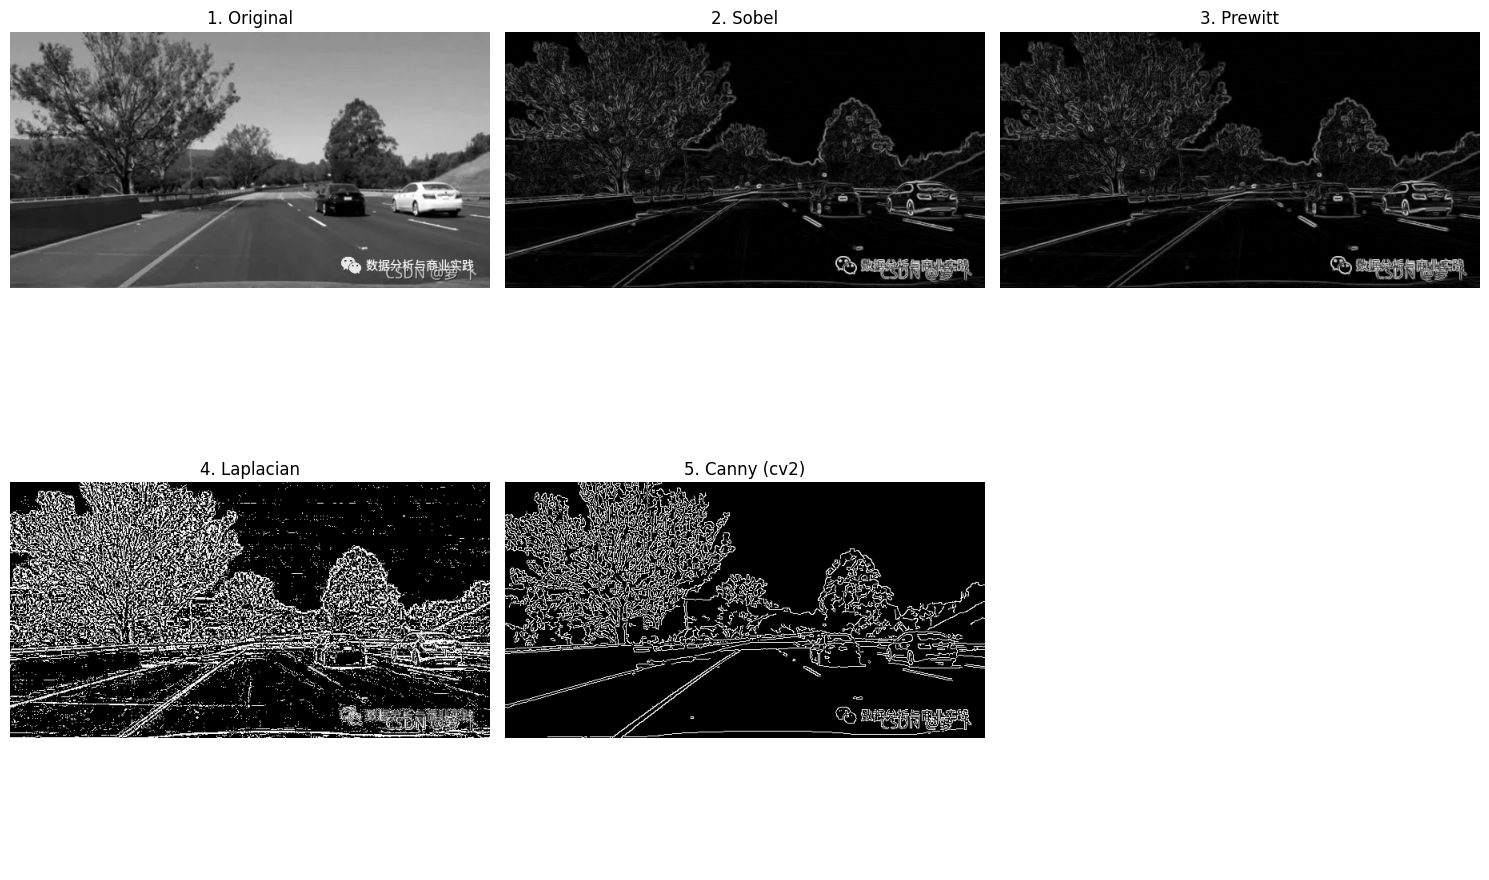

In [7]:
import matplotlib.pyplot as plt

IMAGE_PATH = r'C:\ZC\HIT\Compulsory_Courses\CV\CV_lab\mine\lab1\data\grey_picture.png'  # 替换为你的图像路径
# 读取一张灰度图
image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

# 计算各种边缘
edge_sobel = sobel(image)
edge_prewitt = prewitt(image)
edge_laplacian = laplacian(image)
edge_canny = cv2.Canny(image, 50, 150)  # 随便给个阈值，你后面自己调参

# 可视化
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('1. Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(edge_sobel, cmap='gray')
axes[0, 1].set_title('2. Sobel')
axes[0, 1].axis('off')

axes[0, 2].imshow(edge_prewitt, cmap='gray')
axes[0, 2].set_title('3. Prewitt')
axes[0, 2].axis('off')

axes[1, 0].imshow(edge_laplacian, cmap='gray')
axes[1, 0].set_title('4. Laplacian')
axes[1, 0].axis('off')

axes[1, 1].imshow(edge_canny, cmap='gray')
axes[1, 1].set_title('5. Canny (cv2)')
axes[1, 1].axis('off')

# 第六个格子可以空着或者放你的梯度方向图
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()